## Step 16 — Summary
This notebook has:
- defined a structured Flickr dataset
- downloaded category-based architectural images
- saved metadata for later structural and emotional analysis

Next possible uses:
- YOLO-based structural detection
- SOM clustering
- emotion-driven architectural recomposition

## Step 0 — Define urban morphology categories

Define structured city types that reflect spatial characteristics rather than specific buildings.

These categories will be used throughout the pipeline:
- image dataset collection
- structural detection (YOLO / SAM)
- cross-domain mapping (SOM)
- final spatial recomposition

In [26]:
CITY_TYPE_QUERIES = {
    "desert_city": [
    "desert city architecture sand city",
    "middle eastern desert urban landscape",
    "desert settlement aerial",
    "sandstone desert architecture",
    "arid city skyline"
    ],
    "vertical_city": [
        "futuristic vertical city towers",
        "skyscraper cluster perspective"
    ],
    "circular_city": [
        "circular city layout aerial",
        "radial urban planning city"
    ],
    "desert_city": [
        "desert city architecture sand city",
        "middle eastern desert urban landscape"
    ],
    "ruin_city": [
        "abandoned city ruins overgrown",
        "post apocalyptic city ruins"
    ],
    "layered_city": [
        "multi level city architecture layers",
        "stacked buildings complex urban"
    ],
    "floating_city": [
    "floating city fantasy sky islands",
    "sci fi floating architecture",
    "city on water architecture",
    "elevated urban structures",
    "floating urban habitat"
    ],
    "monumental_city": [
        "grand monumental architecture city",
        "cathedral palace large scale urban"
    ],
    "surreal_city": [
    "surreal city architecture dreamlike",
    "impossible city structures fantasy",
    "dreamlike urban scene",
    "fantasy urban architecture",
    "strange cityscape"
    ]
}

## Step 1 — Import libraries

Import required libraries for:
- API access
- image download
- data handling
- visualization

In [27]:
pip install flickrapi

Note: you may need to restart the kernel to use updated packages.


In [28]:
from pathlib import Path
import pandas as pd
import requests
from tqdm import tqdm
import flickrapi
import matplotlib.pyplot as plt
from PIL import Image
import random

## Step 2 — Setup project paths

Define dataset storage directory.

Images will be saved into structured folders by city type.

In [29]:
PROJECT_ROOT = Path.cwd().resolve().parent

FLICKR_RAW_DIR = PROJECT_ROOT / "data" / "raw" / "flickr_images"
FLICKR_RAW_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset dir:", FLICKR_RAW_DIR)

Dataset dir: D:\Work\Workspace\Projects\Python\data-driven-surface\data\raw\flickr_images


## Step 3 — Setup Flickr API

Connect to Flickr API using your API key and secret.

In [30]:
FLICKR_API_KEY = "62d32f31136292976d51b2d06d9372f2"
FLICKR_API_SECRET = "f9fd75cbd05ebefe"

flickr = flickrapi.FlickrAPI(
    FLICKR_API_KEY,
    FLICKR_API_SECRET,
    format="parsed-json"
)

## Step 4 — Define search function

Search Flickr images using a query and return metadata.

In [31]:
def search_flickr_images(query, per_page=50, page=1):
    response = flickr.photos.search(
        text=query,
        per_page=per_page,
        page=page,
        sort="relevance",
        safe_search=1,
        content_type=1,
        extras="url_c,url_l,url_o,tags,title"
    )
    return response["photos"]["photo"]

## Step 5 — Define download function

Download images from URL and save locally.

In [32]:
def download_image(url, save_path):
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            return True
    except:
        pass
    return False

## Step 6 — Build dataset

Loop through all city types and queries:
- search images
- download images
- store metadata

In [ ]:
records = []

MAX_PER_TYPE = 60
MAX_PAGES = 5
PER_PAGE = 50

for city_type, queries in CITY_TYPE_QUERIES.items():

    type_dir = FLICKR_RAW_DIR / city_type
    type_dir.mkdir(exist_ok=True)

    print(f"\n=== {city_type} ===")

    count = 0

    for query in queries:
        if count >= MAX_PER_TYPE:
            break

        for page in range(1, MAX_PAGES + 1):
            if count >= MAX_PER_TYPE:
                break

            photos = search_flickr_images(query, per_page=PER_PAGE, page=page)

            if not photos:
                continue

            for p in photos:
                if count >= MAX_PER_TYPE:
                    break

                tags = p.get("tags", "").lower()
                title = p.get("title", "").lower()
                text = title + " " + tags

                # ❌ 非真实空间图像
                if any(x in text for x in ["drawing", "painting", "sketch", "illustration", "art"]):
                    continue

                # ❌ 人物主导
                if any(x in text for x in ["portrait", "person", "people", "man", "woman", "face", "selfie"]):
                    continue
                
                url = p.get("url_c") or p.get("url_l") or p.get("url_o")
                if not url:
                    continue

                filename = f"{city_type}_{count}.jpg"
                save_path = type_dir / filename

                if save_path.exists():
                    count += 1
                    continue

                success = download_image(url, save_path)

                if success:
                    records.append({
                        "city_type": city_type,
                        "query": query,
                        "page": page,
                        "image_url": url,
                        "title": p.get("title"),
                        "tags": p.get("tags"),
                        "local_path": str(save_path)
                    })
                    count += 1

    print("Downloaded:", count)


=== desert_city ===
Downloaded: 60

=== vertical_city ===
Downloaded: 60

=== circular_city ===
Downloaded: 60

=== ruin_city ===
Downloaded: 60

=== layered_city ===
Downloaded: 60

=== floating_city ===
Downloaded: 60

=== monumental_city ===
Downloaded: 60

=== surreal_city ===
Downloaded: 60


## Step 7 — Save dataset metadata

Save all image metadata into CSV for later processing.

In [ ]:
df = pd.DataFrame(records)

#csv_path = OUTPUT_TABLES_DIR / "flickr_dataset.csv"

#df.to_csv(csv_path, index=False)

#print("Saved dataset:", csv_path)


Saved dataset: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\tables\flickr_dataset.csv


## Step 8a — Filter out portrait-like and non-spatial images

Remove obvious portrait-like or non-spatial images based on title and tag metadata.
This helps improve the structural consistency of the dataset for later YOLO, SAM, and SOM analysis.

In [ ]:
bad_keywords = ["portrait", "person", "people", "man", "woman", "face"]

mask_text = (
    df["title"].fillna("").str.lower() + " " +
    df["tags"].fillna("").str.lower()
)

df = df[~mask_text.str.contains("|".join(bad_keywords), regex=True)].copy()

print("Total images after metadata filtering:", len(df))
df["city_type"].value_counts()

In [ ]:
csv_path = OUTPUT_TABLES_DIR / "flickr_dataset.csv"

df.to_csv(csv_path, index=False)

print("Saved dataset:", csv_path)

## Step 8 — Dataset summary

Check total images and distribution across categories.

In [35]:
print("Total images:", len(df))
df["city_type"].value_counts()

Total images: 480


city_type
desert_city        60
vertical_city      60
circular_city      60
ruin_city          60
layered_city       60
floating_city      60
monumental_city    60
surreal_city       60
Name: count, dtype: int64

## Step 9 — Visualize distribution

Plot number of images per city type.

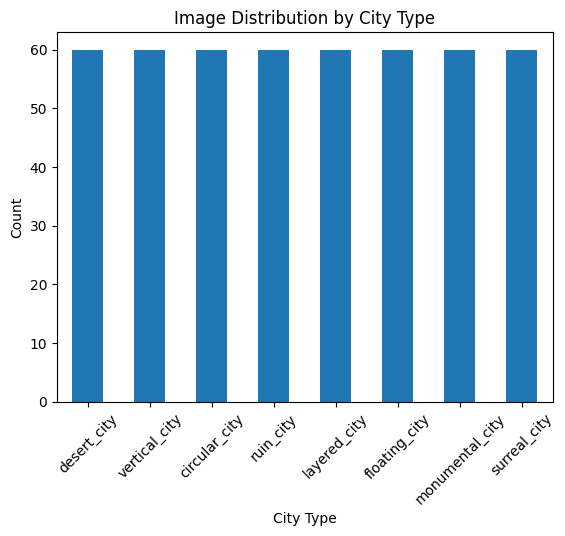

In [36]:
counts = df["city_type"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.title("Image Distribution by City Type")
plt.xlabel("City Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Step 10 — Preview sample images

Display random samples for visual inspection.

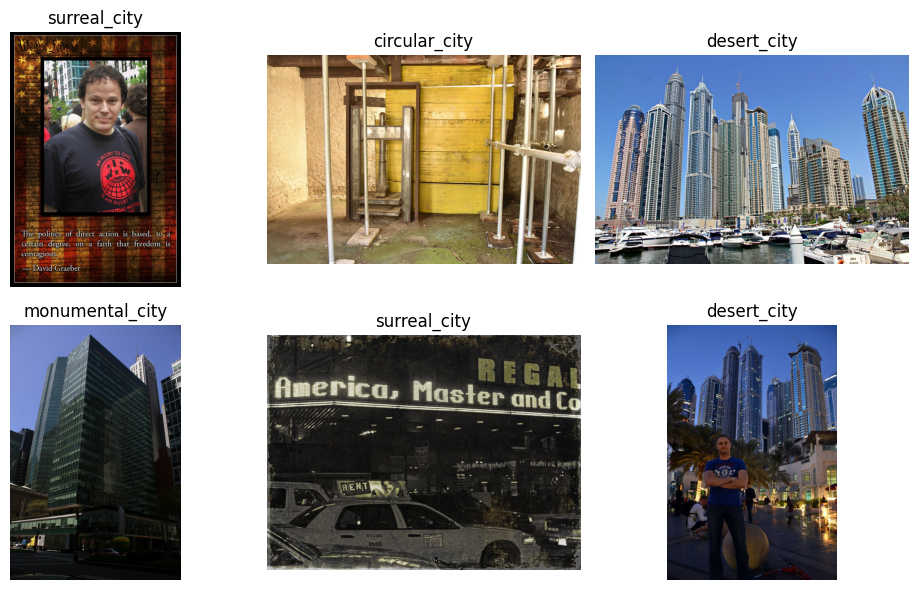

In [37]:
sample = df.sample(6)

plt.figure(figsize=(10,6))

for i, row in enumerate(sample.itertuples()):
    img = Image.open(row.local_path)
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(row.city_type)
    plt.axis("off")

plt.tight_layout()
plt.show()